In [29]:
import langgraph
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal,List
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_core.messages import BaseMessage,HumanMessage
import operator
from langgraph.checkpoint.memory import MemorySaver

In [15]:
load_dotenv()
import os
key = os.getenv("gemini_api")

In [16]:
import langchain_google_genai 
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=key,
    temperature=0.7
)

# State

In [17]:
from langgraph.graph.message import add_messages 

class Chat(TypedDict):
    message: Annotated[List[BaseMessage],add_messages]

# Utility

In [23]:
def interact(state:Chat):
    msg = state['message']
    out = model.invoke(msg).content 
    
    return {'message':[out]}

# Graph

In [30]:
ckpt = MemorySaver()
graph = StateGraph(Chat)

graph.add_node('interact',interact)

graph.add_edge(START,'interact')
graph.add_edge('interact',END)

bot = graph.compile(checkpointer = ckpt)


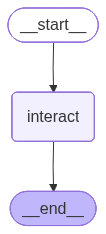

In [25]:
bot

In [26]:
inis = {'message':HumanMessage(content = 'hi my name is sobhin') }
res = bot.invoke(inis)

In [27]:
res

{'message': [HumanMessage(content='hi my name is sobhin', additional_kwargs={}, response_metadata={}, id='bbbf32ea-724d-4f0e-a2f1-92c95a26def2'),
  HumanMessage(content="Hello Sobhin! It's nice to meet you.\n\nHow can I help you today?", additional_kwargs={}, response_metadata={}, id='bead4690-60dc-485e-bec4-95198a8bc399')]}

In [32]:
thread_id = '1'
while True:
    user_msg = input('Type here :')
    print('User_msg:',user_msg)

    if user_msg.strip().lower() in ['exit','bye','quit']:
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    resp = bot.invoke({'message':[HumanMessage(content=user_msg)]},config = config)
    print('AI : ',resp['message'][-1]) 

User_msg: hi my name is sobhin
AI :  content="Hi Sobhin! It's great to meet you.\n\nHow can I assist you today?" additional_kwargs={} response_metadata={} id='ff258699-d0a2-465b-9d4e-c747e4b4c936'
User_msg: what is my name
AI :  content='Your name is **Sobhin**.' additional_kwargs={} response_metadata={} id='057227c5-9cb7-412f-a5c9-d51a55de0852'
User_msg: bye
